In [ ]:
################################################################################################################
################################## FINE- TUNING SANDBOX ########################################################
################################################################################################################

In [ ]:
###### Installations des bibliothéques nécessaires
!pip install peft
!pip install evaluate

In [ ]:
##### Importations des blibliothéques
# pour le traitememt et l'entrainement des données

In [ ]:
## Importation des bibliothéques essentielles pour le traiment des données et le machine learning
import numpy as np
import torch
import pandas as pd
from datasets import Dataset
from sklearn.model_selection import train_test_split    # division entre train et test


## Bibliothéque pour l'évaluation des modéles
import evaluate

In [ ]:
##### Chargement des données ##########

In [ ]:
## pour les films
#from datasets import load_dataset

#dataset = load_dataset("imdb")
#df = dataset["train"].to_pandas()
#df.head()

In [ ]:
!pip install transformers datasets torch scikit-learn

In [ ]:
import pandas as pd
import random

themes = ["hausse des prix", "production stable", "crise agricole", "exportation croissante"]
sentiments = ["positif", "négatif", "neutre"]

data = {
    'texte': [
        f"La situation du marché montre une {random.choice(themes)} cette saison."
        for _ in range(1000)
    ],
    'sentiment': [random.choice(sentiments) for _ in range(1000)]
}

df = pd.DataFrame(data)
df.head()

,texte,sentiment
0,La situation du marché montre une hausse des p...,positif
1,La situation du marché montre une hausse des p...,neutre
2,La situation du marché montre une hausse des p...,neutre
3,La situation du marché montre une exportation ...,neutre
4,La situation du marché montre une production s...,positif


**Encodage des labels**

In [ ]:
# Les modèles de Hugging Face exigent des labels numériques (0, 1, 2).

In [ ]:
label_mapping = {'négatif': 0, 'neutre': 1, 'positif': 2}
df['label'] = df['sentiment'].map(label_mapping)
df.head()

,texte,sentiment,label
0,La situation du marché montre une hausse des p...,positif,2
1,La situation du marché montre une hausse des p...,neutre,1
2,La situation du marché montre une hausse des p...,neutre,1
3,La situation du marché montre une exportation ...,neutre,1
4,La situation du marché montre une production s...,positif,2


**Division en train / test**

In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

**Conversion en Dataset Hugging Face**

In [ ]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

**Chargement du tokenizer DistilBERT**

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize_function(example):
    return tokenizer(
        example["texte"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_tokenized = train_dataset.map(tokenize_function, batched=True)
test_tokenized = test_dataset.map(tokenize_function, batched=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

**Préparation pour l’entraînement**

In [ ]:
# Supprimons les colonnes inutiles :

In [ ]:
train_tokenized = train_tokenized.remove_columns(["texte", "sentiment"])
test_tokenized = test_tokenized.remove_columns(["texte", "sentiment"])

train_tokenized.set_format("torch")
test_tokenized.set_format("torch")

**Chargement du modèle DistilBERT pour classification**

In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=3
)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


**Définition des paramètres d’entraînement**

In [ ]:
!pip install --upgrade transformers

In [ ]:
import transformers
print(transformers.__version__)

4.46.3


In [ ]:
from transformers import TrainingArguments, Trainer

In [ ]:
from transformers import TrainingArguments
print(TrainingArguments)

<class 'transformers.training_args.TrainingArguments'>


In [ ]:
print(type(TrainingArguments))

<class 'type'>


In [ ]:
#!pip uninstall -y transformers
#!pip install transformers==4.46.3

In [ ]:
from transformers import TrainingArguments, Trainer
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='weighted')
    return {"accuracy": acc, "f1": f1}

training_args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    save_strategy="epoch",
    logging_dir="./logs",
    logging_steps=50
)

/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


**Entraînement du modèle**

In [ ]:
# Pour utiliser wandb
#trainer = Trainer(
    #model=model,
    #args=training_args,
    #train_dataset=train_tokenized,
    #eval_dataset=test_tokenized,
    #tokenizer=tokenizer,
    #compute_metrics=compute_metrics
#)

#trainer.train()

In [ ]:
# Ne pas utiliser wandb

training_args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    save_strategy="epoch",
    logging_dir="./logs",
    logging_steps=50,
    report_to=[]  # <-- Désactive wandb et autres loggers
)

/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=test_tokenized,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

trainer.train()

/tmp/ipython-input-907990979.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.100800,1.099293,0.335000,0.248599


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.100800,1.099293,0.335000,0.248599
2,1.100200,1.096509,0.335000,0.248599
3,1.099100,1.096542,0.335000,0.248599


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


TrainOutput(global_step=150, training_loss=1.100022430419922, metrics={'train_runtime': 1909.2083, 'train_samples_per_second': 1.257, 'train_steps_per_second': 0.079, 'total_flos': 79481856614400.0, 'train_loss': 1.100022430419922, 'epoch': 3.0})

**Évaluation finale sur le jeu de test**

In [ ]:
metrics = trainer.evaluate()
print(metrics)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'eval_loss': 1.0965417623519897, 'eval_accuracy': 0.335, 'eval_f1': 0.24859936070405578, 'eval_runtime': 54.749, 'eval_samples_per_second': 3.653, 'eval_steps_per_second': 0.237, 'epoch': 3.0}


**Sauvegarde du modèle entraîné**

In [ ]:
trainer.save_model("C:/Users/GLOBAL/Desktop/DataCamp Certificate DATA SCIENCE/Fine -Tuning")
tokenizer.save_pretrained("C:/Users/GLOBAL/Desktop/DataCamp Certificate DATA SCIENCE/Fine -Tuning")

('C:/Users/GLOBAL/Desktop/DataCamp Certificate DATA SCIENCE/Fine -Tuning/tokenizer_config.json',
 'C:/Users/GLOBAL/Desktop/DataCamp Certificate DATA SCIENCE/Fine -Tuning/special_tokens_map.json',
 'C:/Users/GLOBAL/Desktop/DataCamp Certificate DATA SCIENCE/Fine -Tuning/vocab.txt',
 'C:/Users/GLOBAL/Desktop/DataCamp Certificate DATA SCIENCE/Fine -Tuning/added_tokens.json',
 'C:/Users/GLOBAL/Desktop/DataCamp Certificate DATA SCIENCE/Fine -Tuning/tokenizer.json')

**Test du modèle sur de nouveaux textes**

In [ ]:
from transformers import pipeline

model_path = "C:/Users/GLOBAL/Desktop/DataCamp Certificate DATA SCIENCE/Fine -Tuning"
classifier = pipeline("text-classification", model=model_path, tokenizer=model_path)

texts = [
    "Les exportations agricoles augmentent rapidement.",
    "La récolte de cette année a été catastrophique.",
    "La récolte a connu une hausse",
    "Les prix se sont stabilisés sur le marché."
]

results = classifier(texts)
for txt, res in zip(texts, results):
    print(f"Texte: {txt}\nPrédiction: {res}\n")
#id2label = {0: "négatif", 1: "neutre", 2: "positif"}

Texte: Les exportations agricoles augmentent rapidement.
Prédiction: {'label': 'LABEL_1', 'score': 0.3531592786312103}

Texte: La récolte de cette année a été catastrophique.
Prédiction: {'label': 'LABEL_1', 'score': 0.3474676012992859}

Texte: La récolte a connu une hausse
Prédiction: {'label': 'LABEL_2', 'score': 0.3349847197532654}

Texte: Les prix se sont stabilisés sur le marché.
Prédiction: {'label': 'LABEL_1', 'score': 0.3384283781051636}



**Visualisations pour évaluer la performance de ton modèle après le fine-tuning**

In [ ]:
# Prédictions sur le jeu de test

In [ ]:
import torch
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Préparer le dataloader du test
test_loader = torch.utils.data.DataLoader(test_tokenized, batch_size=16)

model.eval()
preds = []
labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids']
        attention_mask = batch['attention_mask']
        label = batch['label']

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        predictions = torch.argmax(outputs.logits, dim=-1)

        preds.extend(predictions.numpy())
        labels.extend(label.numpy())

In [ ]:
# Matrice de confusion

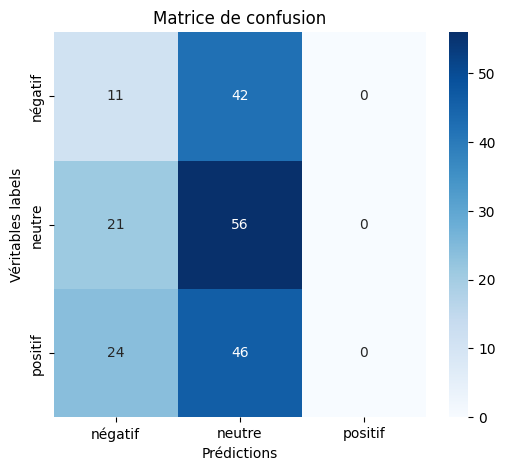

In [ ]:
cm = confusion_matrix(labels, preds)
labels_names = ["négatif", "neutre", "positif"]

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels_names, yticklabels=labels_names, cmap="Blues")
plt.xlabel("Prédictions")
plt.ylabel("Véritables labels")
plt.title("Matrice de confusion")
plt.show()

In [ ]:
# Accuracy et F1 Score

In [ ]:
acc = accuracy_score(labels, preds)
f1 = f1_score(labels, preds, average='weighted')

print(f"Accuracy global: {acc:.3f}")
print(f"F1 Score global: {f1:.3f}")

Accuracy global: 0.335
F1 Score global: 0.249


In [ ]:
# Courbes Accuracy et F1 par époque (si on utilise Trainer)

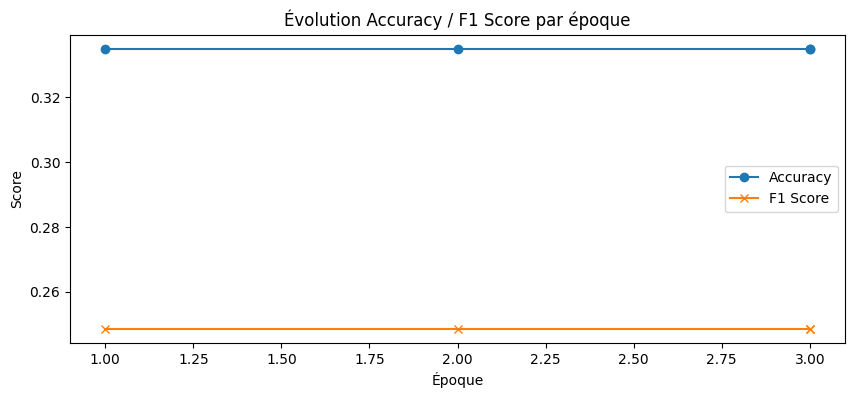

In [ ]:
import pandas as pd

# Récupérer l'historique des metrics
history = trainer.state.log_history
df_history = pd.DataFrame(history)

# Filtrer pour évaluation
df_eval = df_history[df_history['eval_loss'].notna()]

plt.figure(figsize=(10,4))
plt.plot(df_eval['epoch'], df_eval['eval_accuracy'], marker='o', label="Accuracy")
plt.plot(df_eval['epoch'], df_eval['eval_f1'], marker='x', label="F1 Score")
plt.xlabel("Époque")
plt.ylabel("Score")
plt.title("Évolution Accuracy / F1 Score par époque")
plt.legend()
plt.show()